## GWO Validation on Four Benchmark Functions (PSO Parameter Mapping)

- Functions: Rastrigin, Styblinski-Tang, Ackley, Griewank
- dim 10: population size 30, iterations 1000
- dim 30: population size 30, iterations 1000
- dim 50: population size 30, iterations 1000

<!-- notebook-role-marker -->
## Notebook Role
This notebook is an ablation study for the omega birth-death mechanism. Long-term omega agents are renewed by roulette-selected leader guidance and Levy-flight displacement. It is not the final algorithm by itself.

Unified run setting for all result tables: seed rule `BASE_SEED + run`, population size 30, 1000 iterations, 10 independent runs, dimensions 10/30/50, bounds [-5, 5], and the same success criteria for all benchmark functions.

In [1]:
# PSO -> GWO parameter mapping (keep current PSO scale)
# MAX_VELOCITY -> GWO_RANDOM_STEP (local random perturbation amplitude)
# C1 -> GWO_A0 (initial exploration coefficient a)
# C2 -> GWO_NOISE_SCALE (perturbation scaling)
MAX_VELOCITY = 1.0
BOUNDS = [-5, 5]
C1 = 1
C2 = 1
GWO_RANDOM_STEP = MAX_VELOCITY
GWO_A0 = 2.0 * C1
GWO_NOISE_SCALE = 0.03 * C2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def rastrigin(x):
    x = np.asarray(x)
    return 10.0 * x.size + np.sum(x ** 2 - 10.0 * np.cos(2.0 * np.pi * x))

def styblinski_tang(x):
    x = np.asarray(x)
    return 0.5 * np.sum(x ** 4 - 16.0 * x ** 2 + 5.0 * x)

def ackley(x):
    x = np.asarray(x)
    n = x.size
    sum_sq = np.sum(x ** 2)
    sum_cos = np.sum(np.cos(2.0 * np.pi * x))
    return -20.0 * np.exp(-0.2 * np.sqrt(sum_sq / n)) - np.exp(sum_cos / n) + 20.0 + np.e

def griewank(x):
    x = np.asarray(x)
    i = np.arange(1, x.size + 1)
    return np.sum(x ** 2) / 4000.0 - np.prod(np.cos(x / np.sqrt(i))) + 1.0

functions = {
    "Rastrigin": rastrigin,
    "Styblinski-Tang": styblinski_tang,
    "Ackley": ackley,
    "Griewank": griewank,
}

dim_list = [10, 30, 50]
NUM_RUNS = 10
BASE_SEED = 42

# GWO settings mapped from existing PSO-scale setup
GWO_SETTINGS = {d: {"num_particles": 30, "max_iters": 1000} for d in dim_list}

# Success criteria
RAS_TOL_PER_DIM = 1e-2
ST_OPTIMUM_PER_DIM = -39.16616570377142
ST_TOL_PER_DIM = 5e-1
ACKLEY_TOL = 1e-2
GRIEWANK_TOL = 1e-2

In [3]:
import math

class GWO:
    def __init__(self, objective, dim=2, num_particles=30, max_iters=200):
        self.objective = objective
        self.dim = dim
        self.num_particles = num_particles
        self.max_iters = max_iters

        self.positions = np.random.uniform(BOUNDS[0], BOUNDS[1], (num_particles, dim))
        self.history = []

        self.alpha_pos = None
        self.alpha_score = float("inf")

        self.particle_ids = np.arange(num_particles)
        self.omega_streak = np.zeros(num_particles, dtype=int)
        self.omega_drop_threshold = max(1, math.ceil(0.05 * self.max_iters))
        self.drop_count = 0

    @staticmethod
    def _levy_flight_step(dim, beta=1.5):
        sigma_u = (
            (math.gamma(1 + beta) * np.sin(np.pi * beta / 2))
            / (math.gamma((1 + beta) / 2) * beta * (2 ** ((beta - 1) / 2)))
        ) ** (1 / beta)
        u = np.random.normal(0, sigma_u, dim)
        v = np.random.normal(0, 1, dim)
        return u / (np.abs(v) ** (1 / beta) + 1e-12)

    @staticmethod
    def _leader_roulette_index(leader_fitness):
        # Minimization: smaller fitness gets larger weight.
        max_fit = np.max(leader_fitness)
        weights = (max_fit - leader_fitness) + 1e-12
        probs = weights / np.sum(weights)
        return np.random.choice(len(leader_fitness), p=probs)

    def optimize(self):
        for t in range(self.max_iters):
            fitness = np.apply_along_axis(self.objective, 1, self.positions)
            sorted_idx = np.argsort(fitness)
            self.positions = self.positions[sorted_idx]
            fitness = fitness[sorted_idx]
            self.particle_ids = self.particle_ids[sorted_idx]

            alpha = self.positions[0].copy()
            beta = self.positions[1].copy() if self.num_particles > 1 else alpha.copy()
            delta = self.positions[2].copy() if self.num_particles > 2 else beta.copy()

            if fitness[0] < self.alpha_score:
                self.alpha_score = float(fitness[0])
                self.alpha_pos = alpha.copy()

            progress = t / max(1, self.max_iters - 1)
            a = GWO_A0 * (1.0 - progress)

            leaders = [alpha, beta, delta][: min(3, self.num_particles)]
            leader_fitness = fitness[: len(leaders)]

            for i in range(self.num_particles):
                pid = self.particle_ids[i]

                if i >= 3:
                    self.omega_streak[pid] += 1
                else:
                    self.omega_streak[pid] = 0

                if self.omega_streak[pid] > self.omega_drop_threshold:
                    base_idx = self._leader_roulette_index(leader_fitness)
                    base_pos = leaders[base_idx]
                    levy_step = self._levy_flight_step(self.dim)
                    new_pos = base_pos + levy_step * GWO_RANDOM_STEP
                    self.positions[i] = np.clip(new_pos, BOUNDS[0], BOUNDS[1])
                    self.omega_streak[pid] = 0
                    self.drop_count += 1
                    continue

                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)
                A1 = 2.0 * a * r1 - a
                C1v = 2.0 * r2
                D_alpha = np.abs(C1v * alpha - self.positions[i])
                X1 = alpha - A1 * D_alpha

                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)
                A2 = 2.0 * a * r1 - a
                C2v = 2.0 * r2
                D_beta = np.abs(C2v * beta - self.positions[i])
                X2 = beta - A2 * D_beta

                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)
                A3 = 2.0 * a * r1 - a
                C3v = 2.0 * r2
                D_delta = np.abs(C3v * delta - self.positions[i])
                X3 = delta - A3 * D_delta

                new_pos = (X1 + X2 + X3) / 3.0
                perturb = np.random.uniform(-GWO_RANDOM_STEP, GWO_RANDOM_STEP, self.dim) * GWO_NOISE_SCALE * (1.0 - progress)
                self.positions[i] = np.clip(new_pos + perturb, BOUNDS[0], BOUNDS[1])

            self.history.append(self.alpha_score)

        return self.alpha_pos, self.alpha_score, np.array(self.history)

In [4]:
# Rebuild benchmark results (for plotting/summary)
import time

def _is_success(fname, d, best_f):
    if fname == "Rastrigin":
        return abs(best_f) <= RAS_TOL_PER_DIM * d
    if fname == "Styblinski-Tang":
        target = ST_OPTIMUM_PER_DIM * d
        return abs(best_f - target) <= ST_TOL_PER_DIM * d
    if fname == "Ackley":
        return abs(best_f) <= ACKLEY_TOL
    if fname == "Griewank":
        return abs(best_f) <= GRIEWANK_TOL
    return False

results = {fname: {} for fname in functions.keys()}

for fname, fobj in functions.items():
    for d in dim_list:
        run_best = []
        run_hist = []
        run_time = []
        success = []

        for run in range(NUM_RUNS):
            seed = BASE_SEED + run
            np.random.seed(seed)

            gwo = GWO(
                objective=fobj,
                dim=d,
                num_particles=GWO_SETTINGS[d]["num_particles"],
                max_iters=GWO_SETTINGS[d]["max_iters"],
            )

            t0 = time.time()
            best_x, best_f, hist = gwo.optimize()
            t1 = time.time()

            run_best.append(best_f)
            run_hist.append(hist)
            run_time.append(t1 - t0)
            success.append(_is_success(fname, d, best_f))

        hist_mean = np.mean(np.vstack(run_hist), axis=0) if len(run_hist) > 0 else np.array([])
        run_best = np.array(run_best, dtype=float)
        success = np.array(success, dtype=bool)
        run_time = np.array(run_time, dtype=float)

        results[fname][d] = {
            "history": hist_mean,
            "best": float(np.min(run_best)),
            "mean": float(np.mean(run_best)),
            "std": float(np.std(run_best)),
            "worst": float(np.max(run_best)),
            "success_rate": float(np.mean(success) * 100.0),
            "time_mean_sec": float(np.mean(run_time)),
        }

print("results rebuilt.")

results rebuilt.


GWO_borndeath.ipynb:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "cell_type": "code",
=== Rastrigin (10 runs) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	0.000000	0.000000	0.000000	0.000001	100.0		4.2073
30	0.000006	0.000014	0.000004	0.000022	100.0		4.2213
50	0.000059	0.000119	0.000032	0.000170	100.0		4.3397

=== Styblinski-Tang (10 runs) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	-391.661545	-365.905234	17.249609	-338.249998	20.0		4.3080
30	-962.329288	-853.620242	74.258393	-727.537809	0.0		4.5209
50	-1219.477572	-1096.358576	91.262970	-929.159005	0.0		4.5233

=== Ackley (10 runs) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	0.000053	0.000063	0.000008	0.000076	100.0		4.4414
30	0.000181	0.000217	0.000025	0.000247	100.0		4.6383
50	0.000325	0.000411	0.000065	0.000515	100.0		4.7139

=== Griewank (10 runs) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	0.000000	0.009011	0.014273	

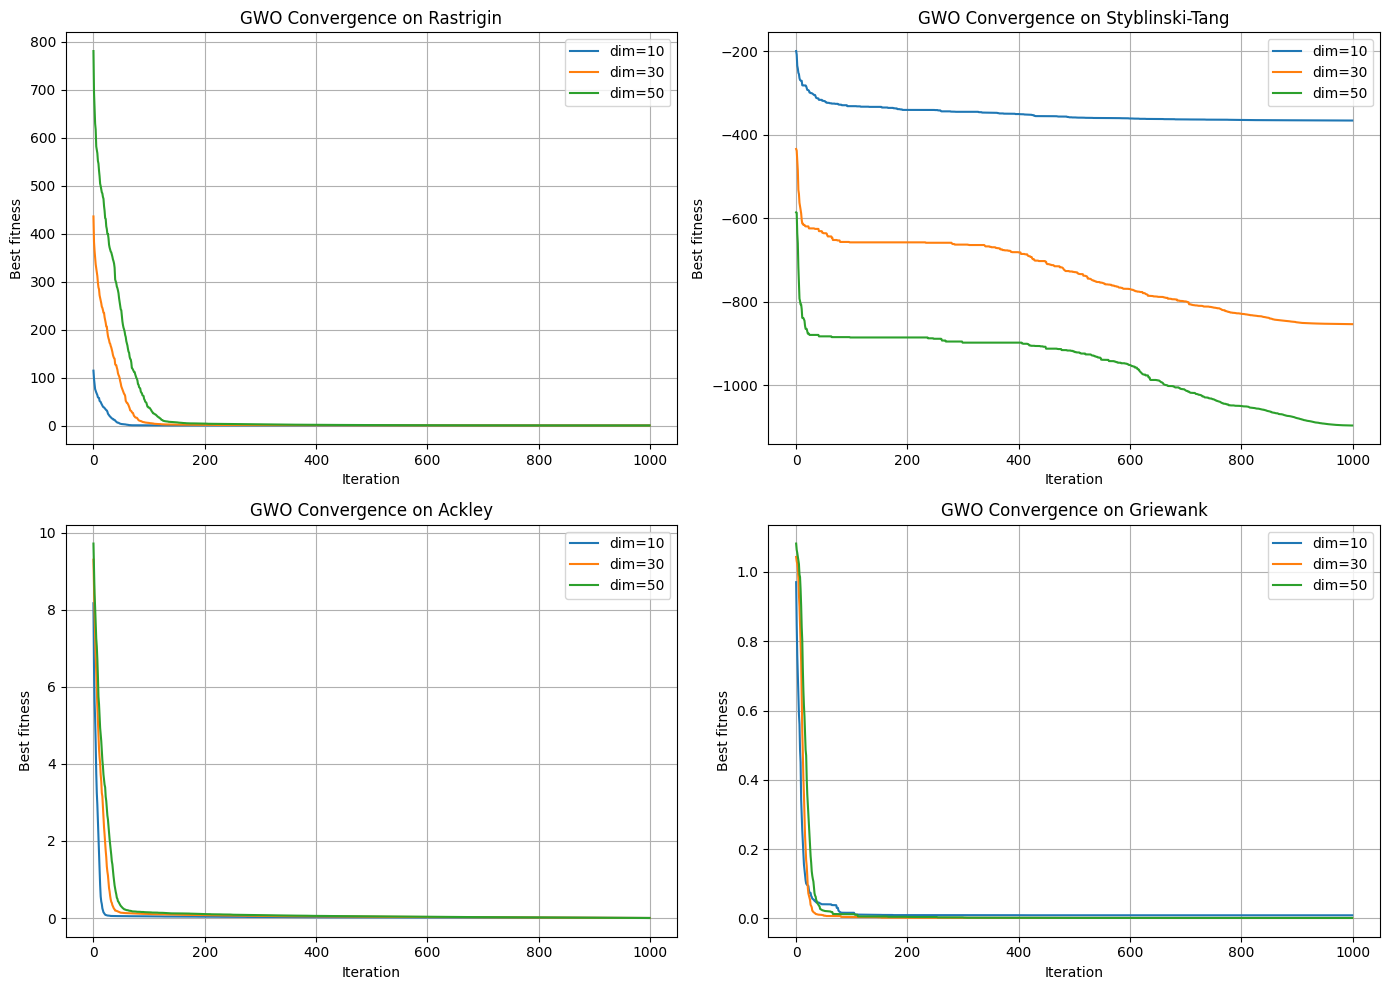

In [5]:
# Plot results for all four functions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, fname in enumerate(functions.keys()):
    ax = axes[idx]
    available_keys = set(results[fname].keys())
    plotted = 0

    for d in dim_list:
        # Support both int and str dimension keys in results.
        dim_data = results[fname].get(d, results[fname].get(str(d)))
        if dim_data is None:
            continue
        ax.plot(dim_data["history"], label=f"dim={d}")
        plotted += 1

    ax.set_title(f"GWO Convergence on {fname}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best fitness")
    ax.grid(True)
    if plotted > 0:
        ax.legend()
    else:
        ax.text(0.5, 0.5, f"No matching dims in results\nkeys={sorted(available_keys)}",
                ha="center", va="center", transform=ax.transAxes)

plt.tight_layout()
plt.show()

for fname in functions.keys():
    print(f"=== {fname} ({NUM_RUNS} runs) ===")
    print("dim\tbest\t\tmean\t\tstd\t\tworst\t\tsuccess_rate(%)\tmean_time(s)")
    for d in dim_list:
        s = results[fname].get(d, results[fname].get(str(d)))
        if s is None:
            print(f"{d}\tN/A\t\tN/A\t\tN/A\t\tN/A\t\tN/A\t\tN/A")
            continue
        print(f"{d}\t{s['best']:.6f}\t{s['mean']:.6f}\t{s['std']:.6f}\t{s['worst']:.6f}\t{s['success_rate']:.1f}\t\t{s['time_mean_sec']:.4f}")
    print()

In [ ]:
# Drop statistics for omega-drop + Levy-flight mechanism
drop_stats = {fname: {} for fname in functions.keys()}

for fname, fobj in functions.items():
    for d in dim_list:
        run_drop = []

        for run in range(NUM_RUNS):
            seed = BASE_SEED + run
            np.random.seed(seed)

            gwo = GWO(
                objective=fobj,
                dim=d,
                num_particles=GWO_SETTINGS[d]["num_particles"],
                max_iters=GWO_SETTINGS[d]["max_iters"],
            )
            _best_x, _best_f, _hist = gwo.optimize()
            run_drop.append(int(gwo.drop_count))

        drop_stats[fname][d] = {
            "run_drop_counts": run_drop,
            "avg_drop_per_run": float(np.mean(run_drop)),
        }

print("=== Drop Trigger Statistics ===")
for fname in functions.keys():
    print(f"[{fname}]")
    for d in dim_list:
        s = drop_stats[fname][d]
        print(f"dim={d}")
        print(f"  per-run drop counts: {s['run_drop_counts']}")
        print(f"  avg drop count (this dim): {s['avg_drop_per_run']:.2f}")
    print()